In [1]:
import os
print(os.getcwd())

D:\DS Projects\Churn_Project


# 1.Importing Data and Checking the quality of dataset

In [2]:
import pandas as pd
import sqlite3

In [3]:
project_path = 'D:/DS Projects/Churn_Project'
if not os.path.exists(project_path):
    os.makedirs(project_path)

In [4]:
#reading the raw data as raw data was downloaded in same folder and saved as Rawchurn.csv
df = pd.read_csv('Rawchurn.csv')
#Checking the data if there is any issue in reading
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#checking for quality and data types of data so that we can strategize further cleaning process
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#checing for duplicates and null values in datasets
print(f"Number of duplicates rows found: {df.duplicated().sum()}")
print("\nMissing values present per column:")
print(df.isnull().sum())

Number of duplicates rows found: 0

Missing values present per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Counting how many rows having blank spaces instead of a number
print("Hidden blank spaces per column:")
print((df == " ").sum())

Hidden blank spaces per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


# 2 Starting To clean Dataset

In [8]:
# Show the rows where TotalCharges is a blank space as We are tying to look at tenure MonthlyCharges
#see what method to apply either zero or first month charge in the missing value
missing_data_rows = df[df['TotalCharges'] == " "]
missing_data_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']]

,tenure,MonthlyCharges,TotalCharges,Contract
488,0,52.55,,Two year
753,0,20.25,,Two year
936,0,80.85,,Two year
1082,0,25.75,,Two year
1340,0,56.05,,Two year
3331,0,19.85,,Two year
3826,0,25.35,,Two year
4380,0,20.00,,Two year
5218,0,19.70,,One year
6670,0,73.35,,Two year


In [9]:
#since we observe the tenure is 0, that singnifies these people has yet to even recieve the bill thus instead of blank space we can replace it with 0.
#Replace the blank spaces with 0
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0)

In [10]:
#since we know the data type of total charge is object, converting it is necessary thus we perform the conversion
df['TotalCharges'] = df['TotalCharges'].replace(" ", 0).astype(float)

#we check
print(f"Type AFTER: {df['TotalCharges'].dtype}")
print("-" * 30)

#Looking at those 11 rows again, should probably show 0.0 without quotes
print("Verification of a previously blank row (Index 488):")
print(df.loc[[488], ['tenure', 'MonthlyCharges', 'TotalCharges']])

Type AFTER: float64
------------------------------
Verification of a previously blank row (Index 488):
     tenure  MonthlyCharges  TotalCharges
488       0           52.55           0.0


In [11]:
#now after cleaning the total chage column we proceed to another cleaning process of Cleaning ID column names to proper numerical for Machine learning algorithms
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

In [17]:
# since 'churn' is in form or yes or no we need to convert 'Churn' to 1 and 0, in this we use map() as it is easy and better handles binary options
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
# Check if the NaNs are gone
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [18]:
# Check unique values for the columns we just mapped
print("Unique values in Churn:", df['Churn'].unique())
print("Unique values in gender:", df['gender'].unique())

Unique values in Churn: [0 1]
Unique values in gender: [1 0]


In [19]:
# Check unique values for the columns we just used map() and replace function on
print("Unique values in Churn:", df['Churn'].unique())
print("Unique values in gender:", df['gender'].unique())

Unique values in Churn: [0 1]
Unique values in gender: [1 0]


In [16]:
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0       1              0     Yes         No       1           No   
1       0              0      No         No      34          Yes   
2       0              0      No         No       2          Yes   
3       0              0      No         No      45           No   
4       1              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [20]:
# This looks for every remaining 'Object' (text) column and turns them into multiple 1/0 columns.
df_final = pd.get_dummies(df)

In [21]:
#seeing how wide the table is?
print(f"New number of columns: {df_final.shape[1]}")
df_final.head()

New number of columns: 45


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,29.85,29.85,0,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,0,34,56.95,1889.50,0,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,0,2,53.85,108.15,1,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,0,45,42.30,1840.75,0,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,1,0,2,70.70,151.65,1,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [22]:
#checking the no of rows and column in dataset
rows, cols = df.shape

print(f"📏 Length (Rows): {rows} customers")
print(f"📐 Breadth (Columns): {cols} features")

📏 Length (Rows): 7043 customers
📐 Breadth (Columns): 20 features


In [23]:
#checking for outliers inorder for data to be ML ready
#here we use Q1 and Q3 as it is interquartile range and most outiers occur here and the 1.5 IOR came from statistical observation by John Turkey

def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    
    print(f"--- {column} ---")
    print(f"Lower Limit: {lower_limit:.2f}, Upper Limit: {upper_limit:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    return outliers

# Run it for MonthlyCharges
outliers_monthly = check_outliers(df, 'MonthlyCharges')

# Run it for TotalCharges
outliers_total = check_outliers(df, 'TotalCharges')

--- MonthlyCharges ---
Lower Limit: -46.02, Upper Limit: 171.38
Number of Outliers: 0
--- TotalCharges ---
Lower Limit: -4683.52, Upper Limit: 8868.67
Number of Outliers: 0


In [24]:
#Schecking for numbers that may move together with Churn
correlations = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

print("--- Correlation Logic ---")
print("Which features 'pull' Churn the most?")
print(correlations)

--- Correlation Logic ---
Which features 'pull' Churn the most?
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
gender            0.008612
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64


In [25]:
#by this observation we got tenure and monthly charges are the enginer for churn or target and a some effect can be observed by total charge and demographic factors as well and negligible change observed in Gender 

In [26]:
# saving the cleaned data
df.to_csv('churn_cleaned.csv', index=False)
print("Saved")

Saved


# 3 Data Visualization and Statistical Analysis

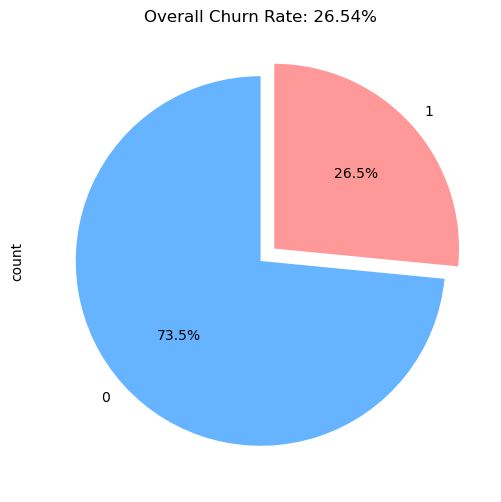

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Churn Rate percentage via the below fomula as the churn column has 1 and 0 value
churn_rate = df['Churn'].mean() * 100

#creating a 1 and 0 pie chart for better visualization
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], explode=[0, 0.1])
plt.title(f'Overall Churn Rate: {churn_rate:.2f}%')
plt.show()

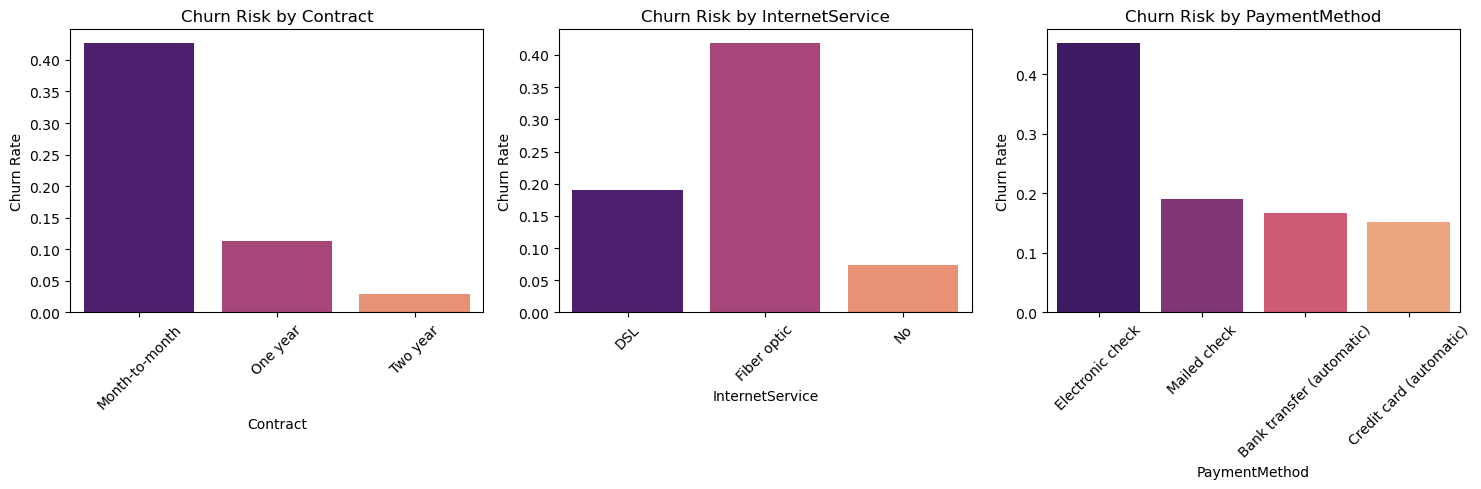

In [30]:
# Let's check Churn across the most suspicious categories the risk analysis stage
features_to_check = ['Contract', 'InternetService', 'PaymentMethod']

plt.figure(figsize=(15, 5))

for i, col in enumerate(features_to_check, 1):
    plt.subplot(1, 3, i)
    # 1. Changed ci=None to errorbar=None
    # 2. Added hue=col and legend=False to fix the palette warning
    sns.barplot(x=col, y='Churn', data=df, hue=col, palette='magma', errorbar=None, legend=False)
    plt.title(f'Churn Risk by {col}')
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

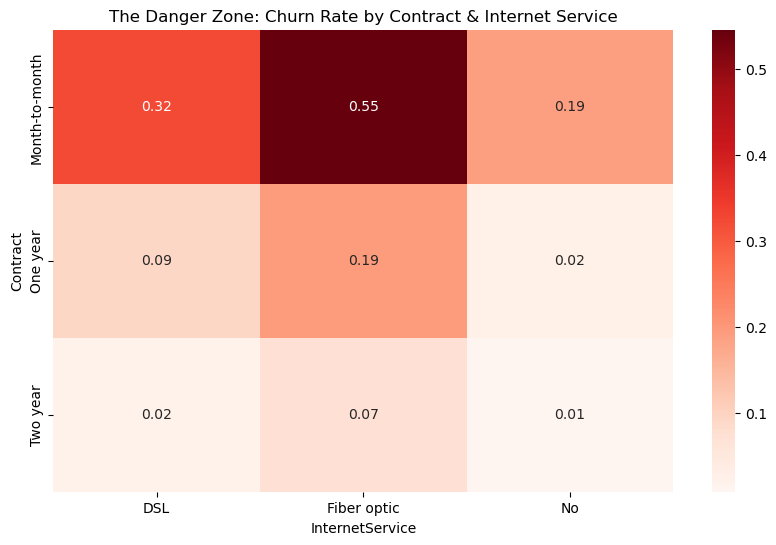

In [31]:
# Create a pivot table to see the interaction between Contract and Internet Service
pivot_table = df.pivot_table(index='Contract', 
                             columns='InternetService', 
                             values='Churn', 
                             aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='Reds', fmt='.2f')
plt.title('The Danger Zone: Churn Rate by Contract & Internet Service')
plt.show()

In [32]:
# 1. This converts all text categories into math-friendly 1s and 0s
df_final = pd.get_dummies(df)

# 2. Let's see the new "Breadth"
print(f"Old Breadth: {df.shape[1]} columns")
print(f"New 'AI-Ready' Breadth: {df_final.shape[1]} columns")

# 3. Preview the change
df_final.head()

Old Breadth: 20 columns
New 'AI-Ready' Breadth: 45 columns


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,29.85,29.85,0,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,0,34,56.95,1889.50,0,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,0,2,53.85,108.15,1,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,0,45,42.30,1840.75,0,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,1,0,2,70.70,151.65,1,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


# 3 Machine Learning

In [33]:
try:
    import sklearn
    print(f"✅ Scikit-Learn is installed! Version: {sklearn.__version__}")
except ImportError:
    print("❌ Scikit-Learn is NOT installed.")

✅ Scikit-Learn is installed! Version: 1.6.1


In [34]:
import sklearn

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [36]:
# Turning text categories into 1s and 0s
df_final = pd.get_dummies(df, drop_first=True)

In [37]:
# Define Features (X) and Target (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

### Running Random Forest 

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Defining the "Brain" first
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Now run the Cross-Validation
# We use the full X and y because the function handles the splitting for us
scores = cross_val_score(rf_model, X, y, cv=5)

print(f"All 5 Scores: {scores}")
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation (Stability): {scores.std():.4f}")

All 5 Scores: [0.79630944 0.78850248 0.77004968 0.8046875  0.79119318]
Average Accuracy: 79.01%
Standard Deviation (Stability): 0.0115


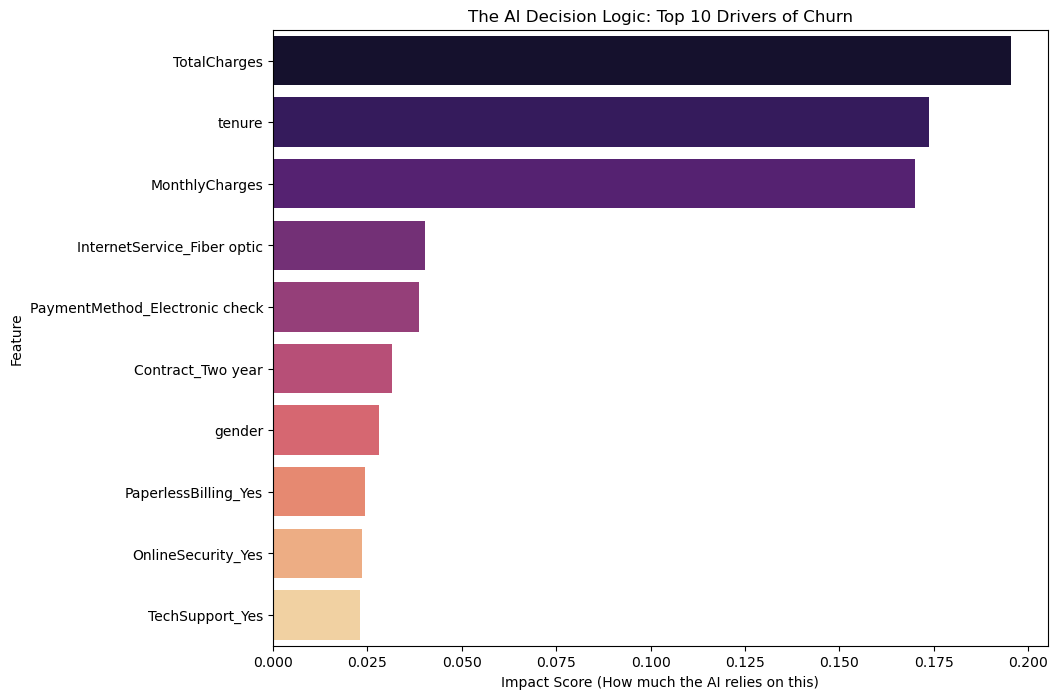

In [42]:
# Manually "Fit" the model so it remembers the data
rf_model.fit(X, y)

# Now that it is fitted, we can pull the importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), 
            hue='Feature', palette='magma', legend=False)
plt.title('The AI Decision Logic: Top 10 Drivers of Churn')
plt.xlabel('Impact Score (How much the AI relies on this)')
plt.show()

In [47]:
# Running to see the REAL names the AI knows
print("--- Exact names the AI expects ---")
print([col for col in X.columns if 'Contract' in col])

--- Exact names the AI expects ---
['Contract_One year', 'Contract_Two year']


In [48]:
def churn_predictor_tool(tenure, monthly_charges, fiber_optic=True, contract_type='Month-to-month'):
    # 1. Create the blank row based on your AI's memory (X)
    test_customer = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # 2. Fill in the numbers
    test_customer['tenure'] = tenure
    test_customer['MonthlyCharges'] = monthly_charges
    test_customer['TotalCharges'] = tenure * monthly_charges 
    
    # 3. Set Fiber Optic (if it exists in columns)
    for col in X.columns:
        if fiber_optic and "Fiber optic" in col:
            test_customer[col] = 1
            
    # 4. Set Contract (The Logic: If M2M, leave both as 0. If 1yr or 2yr, set that specific one to 1)
    if contract_type == 'One year':
        test_customer['Contract_One year'] = 1
    elif contract_type == 'Two year':
        test_customer['Contract_Two year'] = 1
    # Note: If it's Month-to-month, both stay 0 (which is what the AI expects!)

    # 5. Predict
    probability = rf_model.predict_proba(test_customer)[0][1]
    
    print(f"--- 🧪 Simulation Result ---")
    print(f"Customer: {tenure} months | ${monthly_charges}/mo | {contract_type}")
    print(f"Risk Level: {'🔴 HIGH' if probability > 0.5 else '🟢 LOW'}")
    print(f"Churn Probability: {probability:.2%}")
    print("-" * 30)

In [49]:
# --- TEST THE SCENARIOS ---
print("SCENARIO 1: The Month-to-Month Risk")
churn_predictor_tool(2, 105, fiber_optic=True, contract_type='Month-to-month')

print("SCENARIO 2: The Same Customer but on a 2-Year Contract")
churn_predictor_tool(2, 105, fiber_optic=True, contract_type='Two year')

SCENARIO 1: The Month-to-Month Risk
--- 🧪 Simulation Result ---
Customer: 2 months | $105/mo | Month-to-month
Risk Level: 🔴 HIGH
Churn Probability: 63.00%
------------------------------
SCENARIO 2: The Same Customer but on a 2-Year Contract
--- 🧪 Simulation Result ---
Customer: 2 months | $105/mo | Two year
Risk Level: 🟢 LOW
Churn Probability: 41.00%
------------------------------


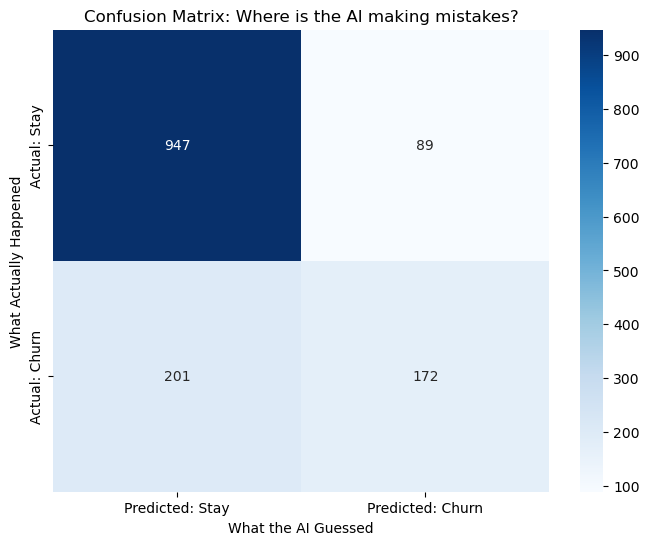

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure we have our split data and predictions ready
# (Using the X and y you defined earlier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit the model if not already done
rf_model.fit(X_train, y_train)

# 3. Generate predictions
y_pred = rf_model.predict(X_test)

# 4. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 5. Visualize it beautifully
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])

plt.xlabel('What the AI Guessed')
plt.ylabel('What Actually Happened')
plt.title('Confusion Matrix: Where is the AI making mistakes?')
plt.show()

In [52]:
import streamlit as st
import pandas as pd
import joblib

# Load the Model and Features
model = joblib.load('churn_model.pkl')
features = joblib.load('model_features.pkl')

# The Web Interface
st.title("📞 Telco Customer Retention Tool")
st.markdown("Predict if a customer will leave and test retention strategies in real-time.")

# Sidebar Inputs (The "Sliders")
st.sidebar.header("Customer Profile")
tenure = st.sidebar.slider("Tenure (Months)", 1, 72, 12)
monthly = st.sidebar.slider("Monthly Charges ($)", 18, 120, 70)
contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
fiber = st.sidebar.selectbox("Internet Service", ["Fiber optic", "DSL", "No"])

# Logic to match the AI's requirements
input_data = pd.DataFrame(0, index=[0], columns=features)
input_data['tenure'] = tenure
input_data['MonthlyCharges'] = monthly
input_data['TotalCharges'] = tenure * monthly

if contract == "One year":
    input_data['Contract_One year'] = 1
elif contract == "Two year":
    input_data['Contract_Two year'] = 1
    
if fiber == "Fiber optic":
    input_data['InternetService_Fiber optic'] = 1

# 5. The Prediction
prob = model.predict_proba(input_data)[0][1]

# 6. Display Result
st.subheader(f"Churn Risk: {prob:.1%}")
if prob > 0.5:
    st.error("⚠️ HIGH RISK: This customer is likely to leave.")
else:
    st.success("✅ LOW RISK: This customer is likely to stay.")

FileNotFoundError: [Errno 2] No such file or directory: 'churn_model.pkl'

In [53]:
!pip install streamlit joblib

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [54]:
import joblib

# This 'dumps' (saves) the variables into actual files on your computer
joblib.dump(rf_model, 'churn_model.pkl')
joblib.dump(X.columns, 'model_features.pkl')

print("✅ Files created successfully!")

✅ Files created successfully!


In [55]:
import os
print(f"Python is looking in this folder: {os.getcwd()}")
print(f"Files inside this folder: {os.listdir()}")

Python is looking in this folder: D:\DS Projects\Churn_Project
Files inside this folder: ['.ipynb_checkpoints', '.virtual_documents', 'churn_cleaned.csv', 'churn_model.pkl', 'Churn_Projects_script.ipynb', 'model_features.pkl', 'Rawchurn.csv']


In [56]:
import streamlit as st
import pandas as pd
import joblib

# Load the Model and Features
model = joblib.load('churn_model.pkl')
features = joblib.load('model_features.pkl')

# The Web Interface
st.title("📞 Telco Customer Retention Tool")
st.markdown("Predict if a customer will leave and test retention strategies in real-time.")

# Sidebar Inputs (The "Sliders")
st.sidebar.header("Customer Profile")
tenure = st.sidebar.slider("Tenure (Months)", 1, 72, 12)
monthly = st.sidebar.slider("Monthly Charges ($)", 18, 120, 70)
contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
fiber = st.sidebar.selectbox("Internet Service", ["Fiber optic", "DSL", "No"])

# Logic to match the AI's requirements
input_data = pd.DataFrame(0, index=[0], columns=features)
input_data['tenure'] = tenure
input_data['MonthlyCharges'] = monthly
input_data['TotalCharges'] = tenure * monthly

if contract == "One year":
    input_data['Contract_One year'] = 1
elif contract == "Two year":
    input_data['Contract_Two year'] = 1
    
if fiber == "Fiber optic":
    input_data['InternetService_Fiber optic'] = 1

# 5. The Prediction
prob = model.predict_proba(input_data)[0][1]

# 6. Display Result
st.subheader(f"Churn Risk: {prob:.1%}")
if prob > 0.5:
    st.error("⚠️ HIGH RISK: This customer is likely to leave.")
else:
    st.success("✅ LOW RISK: This customer is likely to stay.")

2026-03-27 22:45:34.883 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.963 
  command:

    streamlit run C:\Users\user\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-27 22:45:34.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.965 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 22:45:34.967 Thread 'MainThread': mis

In [57]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load the Model and Features
model = joblib.load('churn_model.pkl')
features = joblib.load('model_features.pkl')

st.set_page_config(page_title="Telco Churn Predictor", page_icon="📞")

st.title("📞 Customer Retention Dashboard")
st.markdown("Use the sidebar to adjust customer details and predict churn probability.")

# 2. Sidebar for inputs
st.sidebar.header("Customer Profile")
tenure = st.sidebar.slider("Tenure (Months)", 1, 72, 12)
monthly = st.sidebar.slider("Monthly Charges ($)", 18, 120, 70)
contract = st.sidebar.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
fiber = st.sidebar.selectbox("Internet Service", ["Fiber optic", "DSL", "No"])

# 3. Predict Logic
input_data = pd.DataFrame(0, index=[0], columns=features)
input_data['tenure'] = tenure
input_data['MonthlyCharges'] = monthly
input_data['TotalCharges'] = tenure * monthly

if contract == "One year":
    input_data['Contract_One year'] = 1
elif contract == "Two year":
    input_data['Contract_Two year'] = 1

if fiber == "Fiber optic":
    for col in features:
        if "Fiber optic" in col:
            input_data[col] = 1

# 4. Show Result
prob = model.predict_proba(input_data)[0][1]

st.metric(label="Churn Probability", value=f"{prob:.1%}")

if prob > 0.5:
    st.error("🚨 **High Risk:** This customer is likely to churn.")
else:
    st.success("✅ **Low Risk:** This customer is likely to stay.")

Writing app.py


In [58]:
# This will list all the variables currently in your notebook's memory
%who DataFrame

X	 X_test	 X_train	 df	 df_final	 feature_importance_df	 input_data	 missing_data_rows	 outliers_monthly	 
outliers_total	 pivot_table	 


In [62]:
import joblib

# Use the 'df' version for readable stats
loyal_customers = df[df['Churn'] == 'No']

global_stats = {
    'avg_tenure': float(loyal_customers['tenure'].mean()),
    'avg_monthly_charges': float(loyal_customers['MonthlyCharges'].mean()),
}

joblib.dump(global_stats, 'global_stats.pkl')
print("✅ global_stats.pkl saved! Use this to compare new users to the 'average' loyal customer.")

✅ global_stats.pkl saved! Use this to compare new users to the 'average' loyal customer.


In [65]:
print(df_final.columns.tolist())

['gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


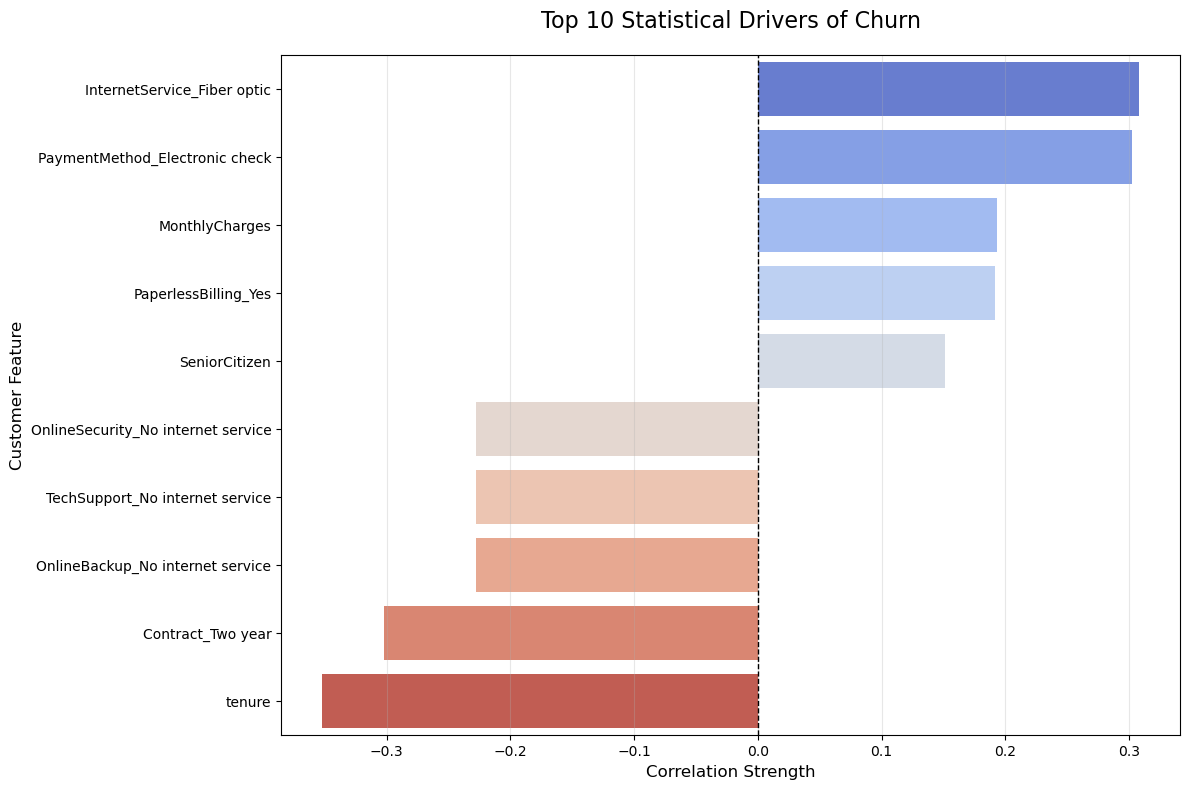

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlations and drop the target itself
correlations = df_final.corr()['Churn'].drop('Churn')

# 2. Get the 5 strongest POSITIVE and 5 strongest NEGATIVE correlations
top_pos = correlations.sort_values(ascending=False).head(5)
top_neg = correlations.sort_values(ascending=True).head(5)

# 3. Combine them into one "Top 10" list
top_10_corr = pd.concat([top_pos, top_neg]).sort_values(ascending=False)

# 4. Create a clean, spacious plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_10_corr.values, 
    y=top_10_corr.index, 
    palette='coolwarm', 
    hue=top_10_corr.index, 
    legend=False
)

# 5. Add a vertical line at 0 and clean labels
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Top 10 Statistical Drivers of Churn', fontsize=16, pad=20)
plt.xlabel('Correlation Strength', fontsize=12)
plt.ylabel('Customer Feature', fontsize=12)
plt.grid(axis='x', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
import joblib

# Capture the insights we found in the plots
stats_to_save = {
    'top_risks': top_pos.index.tolist(),
    'top_loyalty': top_neg.index.tolist(),
    'avg_monthly_charges': float(df['MonthlyCharges'].mean()),
    'avg_tenure': float(df['tenure'].mean())
}

joblib.dump(stats_to_save, 'statistical_insights.pkl')
print("✅ Created statistical_insights.pkl")

✅ Created statistical_insights.pkl


In [72]:
import pandas as pd
import numpy as np

# 1. Use the input_data you already defined in your previous cells
# Assuming 'rf_model' is your trained model
current_prob = rf_model.predict_proba(input_data)[0][1]

# 2. Create a "What-If" scenario: Switching to a Two-Year Contract
# We make a copy so we don't mess up the original input
simulated_data = input_data.copy()

# Look for the contract columns in your features
# Based on your list: 'Contract_One year', 'Contract_Two year'
if 'Contract_One year' in simulated_data.columns:
    simulated_data['Contract_One year'] = 0
if 'Contract_Two year' in simulated_data.columns:
    simulated_data['Contract_Two year'] = 1

# 3. Calculate the new probability
new_prob = rf_model.predict_proba(simulated_data)[0][1]

print(f"Current Churn Probability: {current_prob:.1%}")
print(f"Probability after switching to 2-Year Contract: {new_prob:.1%}")
print(f"Risk Reduction: {current_prob - new_prob:.1%}")

Current Churn Probability: 27.0%
Probability after switching to 2-Year Contract: 23.0%
Risk Reduction: 4.0%


In [73]:
def find_churn_threshold(model, input_data, step=1.0):
    # Copy the user data so we don't change the original
    temp_data = input_data.copy()
    original_charge = temp_data['MonthlyCharges'].values[0]
    current_charge = original_charge
    
    # Loop to reduce charges until probability is < 0.5
    while current_charge > 0:
        prob = model.predict_proba(temp_data)[0][1]
        if prob < 0.5:
            break
        current_charge -= step
        temp_data['MonthlyCharges'] = current_charge
        
    discount_needed = original_charge - current_charge
    return current_charge, discount_needed

# Test it
safe_price, discount = find_churn_threshold(rf_model, input_data)
print(f"Target Price for Safety: ${safe_price:.2f}")
print(f"Suggested Discount: ${discount:.2f}")

Target Price for Safety: $70.00
Suggested Discount: $0.00


In [74]:
def get_feature_sensitivity(model, input_data):
    base_prob = model.predict_proba(input_data)[0][1]
    sensitivity = []

    # Iterate through columns to see which one "hurts" the most
    for col in input_data.columns:
        temp_data = input_data.copy()
        
        # We "neutralize" the feature to see how much the risk drops
        # For numeric, we set to 0. For binary, we flip it.
        temp_data[col] = 0 
        
        new_prob = model.predict_proba(temp_data)[0][1]
        impact = base_prob - new_prob
        sensitivity.append({'Feature': col, 'Impact': impact})

    sensitivity_df = pd.DataFrame(sensitivity).sort_values(by='Impact', ascending=False)
    return sensitivity_df.head(3)

# Test it
top_drivers = get_feature_sensitivity(rf_model, input_data)
print("Top 3 Reasons for this specific User's Risk:")
print(top_drivers)

Top 3 Reasons for this specific User's Risk:
                        Feature  Impact
10  InternetService_Fiber optic    0.03
0                        gender    0.00
3                MonthlyCharges    0.00


In [75]:
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load all your assets
model = joblib.load('churn_model.pkl')
features = joblib.load('model_features.pkl')
stats = joblib.load('statistical_insights.pkl') # The new file you just made

In [76]:
def get_feature_sensitivity(model, input_df):
    base_prob = model.predict_proba(input_df)[0][1]
    sensitivity = []
    for col in input_df.columns:
        temp_df = input_df.copy()
        temp_df[col] = 0  # Neutralize the feature
        new_prob = model.predict_proba(temp_df)[0][1]
        sensitivity.append({'Feature': col, 'Impact': base_prob - new_prob})
    return pd.DataFrame(sensitivity).sort_values(by='Impact', ascending=False).head(3)

def find_churn_threshold(model, input_df):
    temp_df = input_df.copy()
    original_charge = temp_df['MonthlyCharges'].values[0]
    current_charge = original_charge
    while current_charge > 0:
        if model.predict_proba(temp_df)[0][1] < 0.5:
            break
        current_charge -= 1.0
        temp_df['MonthlyCharges'] = current_charge
    return current_charge, original_charge - current_charge

In [77]:
if st.button('Analyze Customer'):
    # 1. Get Prediction
    prob = model.predict_proba(input_df)[0][1]
    prediction = "Churn" if prob > 0.5 else "Loyal"
    
    # 2. Create Tabs
    tab1, tab2, tab3 = st.tabs(["🎯 Prediction", "🔍 Why?", "🛠️ Retention Strategy"])

    with tab1:
        st.header(f"Result: {prediction}")
        st.metric("Churn Probability", f"{prob:.1%}")
        st.progress(prob)
        
    with tab2:
        st.subheader("Top Risk Drivers for this User")
        sensitivity_df = get_feature_sensitivity(model, input_df)
        
        # Display as a nice bar chart
        fig, ax = plt.subplots()
        sns.barplot(x='Impact', y='Feature', data=sensitivity_df, palette='Reds_r', ax=ax)
        st.pyplot(fig)
        st.write("These features are pushing the customer toward leaving.")

    with tab3:
        if prob > 0.5:
            safe_price, discount = find_churn_threshold(model, input_df)
            st.warning(f"**Action Required:** To move this customer to the 'Safe' zone:")
            st.write(f"- Reduce Monthly Charges by: **${discount:.2f}**")
            st.write(f"- Target Monthly Charge: **${safe_price:.2f}**")
        else:
            st.success("This customer is statistically stable. No immediate discount required.")

    # 4. Global Stats (Using your .pkl)
    st.divider()
    st.subheader("📊 Global Market Context")
    col1, col2 = st.columns(2)
    col1.write("**Top 5 Market Risks:**")
    col1.write(stats['top_risks'])
    col2.write("**Top 5 Loyalty Drivers:**")
    col2.write(stats['top_loyalty'])

2026-03-28 02:16:54.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:16:54.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:16:54.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:16:54.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:16:54.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [78]:
import streamlit as st
import joblib

# Load everything
model = joblib.load('churn_model.pkl')
features = joblib.load('model_features.pkl')
# Add this line to load your new insights
stats = joblib.load('statistical_insights.pkl')

In [79]:
st.write(f"The average loyal customer pays: ${stats['avg_monthly_charges']:.2f}")

if st.checkbox("Show Market Trends"):
    st.write("Top Risk Factors in the industry:", stats['top_risks'])

2026-03-28 02:22:30.822 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.831 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.834 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 02:22:30.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
